In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the data
data = pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

- Part B: Dataset Understanding & Preparation

- Tasks:
    
    7. Identify independent and dependent variables.
    
    8. Visualize relationships between features and target variable.
    
    9. Split the dataset into training and testing sets.

In [3]:
# remove unnecessary columns
data = data.drop(columns={"house_id"})

In [4]:
# Identify independent and dependent variable
"""house_price_inr is dependent variable and rest of the columns in the dataset are independent variable"""

'house_price_inr is dependent variable and rest of the columns in the dataset are independent variable'

- Part C: Simple Linear Regression

10. Implement Simple Linear Regression using one feature (e.g., House Area).

11. Plot the regression line and interpret the slope and intercept.

12. Validate linear regression assumptions using plots and observations.

In [5]:
# create the standard and min-max scaler
std_scaler = sklearn.preprocessing.StandardScaler()
min_max_scaler = sklearn.preprocessing.MinMaxScaler()

# combine different transformation techniques using column-transformer
simple_linear_preprocessor = sklearn.compose.ColumnTransformer([
    ('std',std_scaler,["area_sqft"])
])

In [6]:
# build a single linear regression pipeline
simple_linear_reg_pipeline = sklearn.pipeline.Pipeline([
    # scaling the feature doesn't improve the model performance
    # ('preprocess', simple_linear_preprocessor),
    ('simple_linear_algo', sklearn.linear_model.LinearRegression())
])

# split the data 
x = data[["area_sqft"]]
y = data["house_price_inr"]

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.2, random_state=0)

print(f"Training data set shape: {x_train.shape}")
print(f"Testing data set shape: {x_test.shape}")

# fit the model
simple_linear_reg_pipeline.fit(x_train, y_train)

# predict the target variable
y_pred_using_simple_linear_reg = simple_linear_reg_pipeline.predict(x_test)

Training data set shape: (3360, 1)
Testing data set shape: (840, 1)


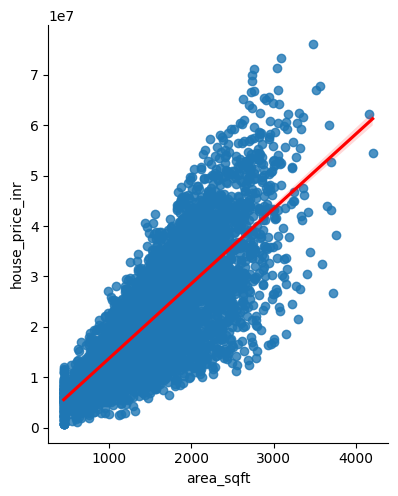

simple Linear Regression model's slope is [14779.18792096]
Single Linear Regression model's intercept is -1030118.3301756233


In [7]:
# plot the regression line and interpret the slope and intercept
sns.pairplot(data = data,x_vars = "area_sqft",y_vars = "house_price_inr", height=5, aspect=0.8, kind="reg", plot_kws={'line_kws': {'color': 'red'}})
plt.show()

print(f"simple Linear Regression model's slope is {simple_linear_reg_pipeline.named_steps['simple_linear_algo'].coef_}")
print(f"Single Linear Regression model's intercept is {simple_linear_reg_pipeline.named_steps['simple_linear_algo'].intercept_}")

- Part D: Model Evaluation Metrics

13. Evaluate the Simple Linear Regression model using:
    - Mean Squared Error (MSE)
    - Mean Absolute Error (MAE)
    - Root Mean Squared Error (RMSE)
    - R2 Score
    - Adjusted R2 Score
14. Interpret each metric and explain what it reveals about model performance.

In [8]:
# evaluate the single linear regression model

# r2 score tell us, How well the model fits the data. 1 is perfect, 0 is bad. 
print(f"\nR2 Score of Simple Linear Regression: {sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg)}")

# Average difference between predicted and actual values. Lower is better. 
print(f"Mean Absolute Error of Simple Linear Regression: {sklearn.metrics.mean_absolute_error(y_test, y_pred_using_simple_linear_reg)}")

# Square of RMSE. Lower is better.
print(f"Mean Squared Error of Simple Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_simple_linear_reg)}")

# Similar to MAE, but penalizes larger errors more. Lower is better.
print(f"Root Mean Squared Error of Simple Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_simple_linear_reg)}")


R2 Score of Simple Linear Regression: 0.5845309896582866
Mean Absolute Error of Simple Linear Regression: 6251423.865977831
Mean Squared Error of Simple Linear Regression: 66539144422025.64
Root Mean Squared Error of Simple Linear Regression: 66539144422025.64


- Part E: Multiple Linear Regression

15. Implement Multiple Linear Regression using all relevant features.

16. Compare its performance with Simple Linear Regression.

17. Explain why performance improves or degrades.

In [9]:
# for i in data.columns:
#     print(f"column:{i}, min:{data[i].min()}, max:{data[i].max()}")

In [10]:
# combine different transformation techniques using column-transformer
multi_linear_preprocessor = sklearn.compose.ColumnTransformer([
    ('std',std_scaler,["area_sqft","lot_size_sqft"]),
    ('min-max',min_max_scaler,["distance_city_km","renovation_years_ago","age_years"])
])

# build a single linear regression pipeline
multi_linear_reg_pipeline = sklearn.pipeline.Pipeline([
    # scaling the feature doesn't improve the model performance
    # ('preprocess', multi_linear_preprocessor),
    ('single_linear_algo', sklearn.linear_model.LinearRegression())
])

# split the data 
x_multi = data.drop(columns={"house_price_inr"})
y_multi = data["house_price_inr"]

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x_multi, y_multi, test_size=0.2, random_state=0)

print(f"Training data set shape: {x_train.shape}")
print(f"Testing data set shape: {x_test.shape}")

# fit the model
multi_linear_reg_pipeline.fit(x_train, y_train)

# predict the target variable
y_pred_using_multi_linear_reg = multi_linear_reg_pipeline.predict(x_test)

# evaluate the multi linear regression model

print(f"\nR2 Score of Multi Linear Regression: {sklearn.metrics.r2_score(y_test, y_pred_using_multi_linear_reg)}")
print(f"Mean Absolute Error of Multi Linear Regression: {sklearn.metrics.mean_absolute_error(y_test, y_pred_using_multi_linear_reg)}")
print(f"Mean Squared Error of Multi Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_multi_linear_reg)}")
print(f"Root Mean Squared Error of Multi Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_multi_linear_reg)}")

Training data set shape: (3360, 10)
Testing data set shape: (840, 10)

R2 Score of Multi Linear Regression: 0.9191593279706751
Mean Absolute Error of Multi Linear Regression: 2598830.6594955386
Mean Squared Error of Multi Linear Regression: 12946980442437.096
Root Mean Squared Error of Multi Linear Regression: 12946980442437.096


In [11]:
# compare simple Regression model Vs Multi Linear Regression model
if sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg) > sklearn.metrics.r2_score(y_test, y_pred_using_multi_linear_reg):
    print(f"Simple Linear Regression model is better than Multi Linear Regression model due to its single feature with {sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg)} R2 Score!")
else:
    print(f"Multi Linear Regression model is better than Simple Linear Regression model due to its multi features with {sklearn.metrics.r2_score(y_test, y_pred_using_multi_linear_reg)} R2 Score!")

Multi Linear Regression model is better than Simple Linear Regression model due to its multi features with 0.9191593279706751 R2 Score!


- Part F: Polynomial Regression

18. Implement Polynomial Regression (degree 2 or 3).

19. Compare linear vs polynomial regression visually and numerically.

20. Identify signs of overfitting or underfitting.

In [12]:
# Implement polynomial regression
# don't need to add degree, because when i add degree model reduce its accuracy

polynomial_reg_pipeline = sklearn.pipeline.Pipeline([
    ('algo',sklearn.linear_model.LinearRegression())
])

poly_features = sklearn.preprocessing.PolynomialFeatures()
x_poly = poly_features.fit_transform(x)
y = data["house_price_inr"]
# split the data
x_poly_train, x_poly_test, y_poly_train, y_poly_test = sklearn.model_selection.train_test_split(x_poly, y, test_size=0.2, random_state=0) 

# fit the model
polynomial_reg_pipeline.fit(x_poly_train, y_poly_train)

# predict the target variable
y_pred_using_poly_reg = polynomial_reg_pipeline.predict(x_poly_test)

# evaluate the model
print(f"\nR2 Score of Polynomial Linear Regression: {sklearn.metrics.r2_score(y_test, y_pred_using_poly_reg)}")
print(f"Mean Absolute Error of Polynomial Linear Regression: {sklearn.metrics.mean_absolute_error(y_test, y_pred_using_poly_reg)}")
print(f"Mean Squared Error of Polynomial Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_poly_reg)}")
print(f"Root Mean Squared Error of Polynomial Linear Regression: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_poly_reg)}")


R2 Score of Polynomial Linear Regression: 0.5847722847520852
Mean Absolute Error of Polynomial Linear Regression: 6243793.185936181
Mean Squared Error of Polynomial Linear Regression: 66500499977566.625
Root Mean Squared Error of Polynomial Linear Regression: 66500499977566.625


In [13]:
# compare simple Regression model Vs Polynomial Linear Regression model
if sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg) > sklearn.metrics.r2_score(y_test, y_pred_using_poly_reg):
    print(f"Simple Linear Regression model is better than Polynomial Linear Regression model due to its single feature with {sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg)} R2 Score!")
else:
    print(f"Polynomial Linear Regression model is better than Simple Linear Regression model due to its polynomial features with {sklearn.metrics.r2_score(y_test, y_pred_using_poly_reg)} R2 Score!")

Polynomial Linear Regression model is better than Simple Linear Regression model due to its polynomial features with 0.5847722847520852 R2 Score!


In [14]:
# compare simple regression model Vs polynomial linear regression visually
# sns.pairplot(data = data,x_vars = "area_sqft",y_vars = "house_price_inr", height=5, aspect=0.8, kind="reg", plot_kws={'line_kws': {'color': 'red'}})
# plt.show()

- Part G: Gradient Descent Optimization

21. Explain Gradient Descent conceptually.

22. Implement Batch Gradient Descent from scratch.

23. Implement Stochastic Gradient Descent (SGD).

24. Implement Mini-Batch Gradient Descent.

25. Compare convergence behavior and training time of all three methods.

In [15]:
# Gradient Descent is an optimization algorithm used to minimize the loss function in various machine learning algorithms.

In [16]:
# Implement the Batch Gradient Descent
# Batch Gradient Descent isn't explicitly used, LinearRegression() uses Batch Gradient Descent internally

# build a BGD pipeline
batch_gd_pipeline = sklearn.pipeline.Pipeline([
    ('BGD',sklearn.linear_model.LinearRegression())
])

# fit the model
batch_gd_pipeline.fit(x_train, y_train)

# predict the target variable
y_pred_using_bgd = batch_gd_pipeline.predict(x_test)

# evaluate the model
print(f"R2 Score of Batch Gradient Descent: {sklearn.metrics.r2_score(y_test, y_pred_using_bgd)}")
print(f"Mean Absolute Error of Batch Gradient Descent: {sklearn.metrics.mean_absolute_error(y_test, y_pred_using_bgd)}")
print(f"Root Mean Squared Error of Batch Gradient Descent: {sklearn.metrics.root_mean_squared_error(y_test, y_pred_using_bgd)}")
print(f"Mean Squared Error of Batch Gradient Descent: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_bgd)}")

R2 Score of Batch Gradient Descent: 0.9191593279706751
Mean Absolute Error of Batch Gradient Descent: 2598830.6594955386
Root Mean Squared Error of Batch Gradient Descent: 3598191.2737425584
Mean Squared Error of Batch Gradient Descent: 12946980442437.096


In [17]:
# Implement the Stochastic Gradient Descent
# it is available as SGDRegressor or SGDClassifier

# build a BGD pipeline
sgd_pipeline = sklearn.pipeline.Pipeline([
    ('SGD',sklearn.linear_model.SGDRegressor())
])

# fit the model
sgd_pipeline.fit(x_train, y_train)

# predict the target variable
y_pred_using_sgd = sgd_pipeline.predict(x_test)

# evaluate the model
print(f"R2 Score of Stochastic Gradient Descent: {sklearn.metrics.r2_score(y_test, y_pred_using_sgd)}")
print(f"Mean Absolute Error of Stochastic Gradient Descent: {sklearn.metrics.mean_absolute_error(y_test, y_pred_using_sgd)}")
print(f"Root Mean Squared Error of Stochastic Gradient Descent: {sklearn.metrics.root_mean_squared_error(y_test, y_pred_using_sgd)}")
print(f"Mean Squared Error of Batch Gradient Descent: {sklearn.metrics.mean_squared_error(y_test, y_pred_using_sgd)}")

R2 Score of Stochastic Gradient Descent: -2.573417659446556e+16
Mean Absolute Error of Stochastic Gradient Descent: 1753894108404431.8
Root Mean Squared Error of Stochastic Gradient Descent: 2030132701216911.2
Mean Squared Error of Batch Gradient Descent: 4.1214387845502726e+30


- Part H: Bias-Variance & Model Diagnostics

26. Analyze bias and variance across:
    - Simple Linear Regression
    - Multiple Linear Regression
    - Polynomial Regression
27. Explain how model complexity affects prediction error.
28. Identify which model best balances bias and variance.

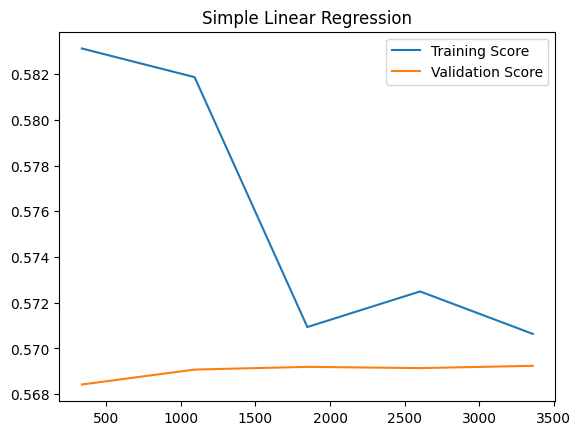

In [18]:
# check bias and variance in simple linear regression
train_sizes, train_scores, val_scores = sklearn.model_selection.learning_curve(simple_linear_reg_pipeline, x, y, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation Score')
plt.legend()
plt.title('Simple Linear Regression')
plt.show()

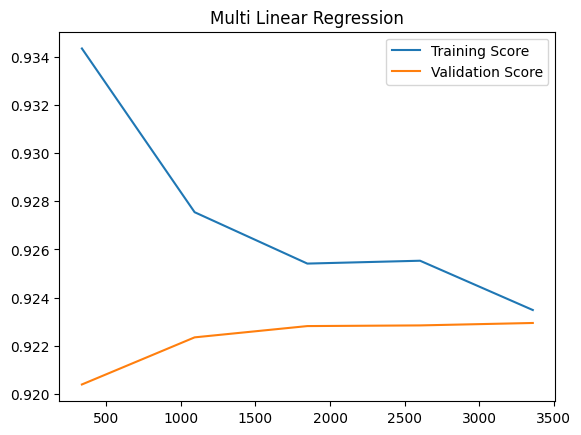

In [19]:
# check bias and variance in simple linear regression
train_sizes, train_scores, val_scores = sklearn.model_selection.learning_curve(multi_linear_reg_pipeline, x_multi, y_multi, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation Score')
plt.legend()
plt.title('Multi Linear Regression')
plt.show()

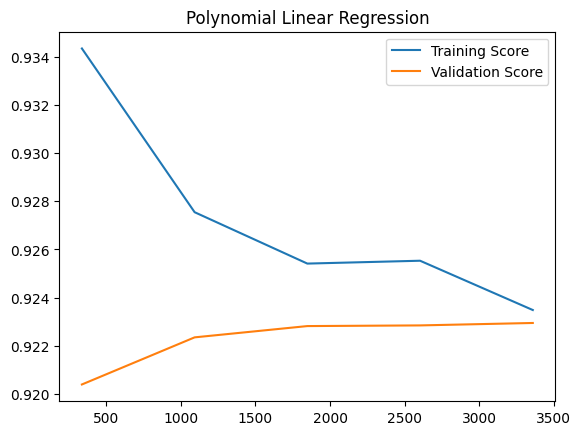

In [20]:
# check bias and variance in simple linear regression
train_sizes, train_scores, val_scores = sklearn.model_selection.learning_curve(polynomial_reg_pipeline, x_multi, y_multi, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation Score')
plt.legend()
plt.title('Polynomial Linear Regression')
plt.show()


- According to the plots, The Multiple Linear Regression model best balances bias and variance, demonstrating a good fit with relatively low error and minimal overfitting.

- Part I: Final Analysis & Reporting

29. Summarize findings in a short report covering:
    - Best-performing model and why
    - Impact of gradient descent optimization
    - Evidence of overfitting/underfitting
    - Practical business interpretation of results
30. Submit:
    - Source code
    - Model evaluation results
    - Graphs and plots
    - Final conclusion

In [28]:
simple_linear_reg_r2_score = sklearn.metrics.r2_score(y_test, y_pred_using_simple_linear_reg)
multi_linear_reg_r2_score = sklearn.metrics.r2_score(y_test, y_pred_using_multi_linear_reg)
poly_linear_reg_r2_score = sklearn.metrics.r2_score(y_test, y_pred_using_poly_reg)
sgd_r2_score = sklearn.metrics.r2_score(y_test, y_pred_using_sgd)
bgd_r2_score = sklearn.metrics.r2_score(y_test, y_pred_using_bgd)

if simple_linear_reg_r2_score > multi_linear_reg_r2_score > poly_linear_reg_r2_score > bgd_r2_score > sgd_r2_score:
    print(f"Best performing model for this dataset is Simple Linear Regression with {simple_linear_reg_r2_score} R2 Score!")

elif multi_linear_reg_r2_score > simple_linear_reg_r2_score > poly_linear_reg_r2_score > bgd_r2_score > sgd_r2_score:
    print(f"Best performing model for this dataset is Multi Linear Regression with {multi_linear_reg_r2_score} R2 Score!")

elif poly_linear_reg_r2_score > simple_linear_reg_r2_score > multi_linear_reg_r2_score > bgd_r2_score > sgd_r2_score:
    print(f"Best performing model for this dataset is Polynomial Linear Regression with {poly_linear_reg_r2_score} R2 Score!")

elif bgd_r2_score > simple_linear_reg_r2_score > multi_linear_reg_r2_score > poly_linear_reg_r2_score > sgd_r2_score:
    print(f"Best performing model for this dataset is Batch Gradient Descent with {bgd_r2_score} R2 Score!")

else:
    print(f"Best performing model for this dataset is Stochastic Gradient Descent with {sgd_r2_score} R2 Score!")

Best performing model for this dataset is Stochastic Gradient Descent with -2.573417659446556e+16 R2 Score!
